# 🩺 EDA — Athlete Injury Risk Detection

Data exploration (Week 1 of the plan):

1. **Audit of the 4 candidate Kaggle datasets** (size, target, balance, temporal dimension)
2. **SIRP-600 focus** (retained real dataset): distributions & class imbalance
3. **Synthetic dataset**: ACWR, load zones, time series, imbalance
4. **Correlations** & conclusions

> Key finding: no real dataset has a daily time series → the ACWR is only computable on the synthetic dataset (dual-track strategy).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.width', 200)
RAW = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'

## 1. Audit of the candidate datasets

In [2]:
mrsimple = pd.read_csv(RAW / 'injury-prediction-mrsimple07' / 'injury_data.csv')
univ = pd.read_csv(RAW / 'university-football-injury' / 'data.csv')
epl = pd.read_csv(RAW / 'epl-player-injuries' / 'player_injuries_impact.csv')
sirp = pd.read_excel(RAW / 'sirp-600' / 'High_Accuracy_Sport_Injury_Dataset.xlsx')

audit = pd.DataFrame([
    {'dataset': 'mrsimple07', 'rows': len(mrsimple), 'columns': mrsimple.shape[1],
     'target': 'Likelihood_of_Injury',
     'balance': mrsimple['Likelihood_of_Injury'].value_counts(normalize=True).round(2).to_dict(),
     'temporal': 'no (snapshot)'},
    {'dataset': 'university-football', 'rows': len(univ), 'columns': univ.shape[1],
     'target': 'Injury_Next_Season',
     'balance': univ['Injury_Next_Season'].value_counts(normalize=True).round(2).to_dict(),
     'temporal': 'no (snapshot)'},
    {'dataset': 'epl-injuries', 'rows': len(epl), 'columns': epl.shape[1],
     'target': 'none (match impact)', 'balance': '-', 'temporal': 'match history'},
    {'dataset': 'sirp-600', 'rows': len(sirp), 'columns': sirp.shape[1],
     'target': 'Injury_Risk',
     'balance': sirp['Injury_Risk'].value_counts(normalize=True).round(2).to_dict(),
     'temporal': 'no (snapshot)'},
])
audit

,dataset,rows,columns,target,balance,temporal
0,mrsimple07,1000,7,Likelihood_of_Injury,"{0: 0.5, 1: 0.5}",no (snapshot)
1,university-football,800,19,Injury_Next_Season,"{0: 0.5, 1: 0.5}",no (snapshot)
2,epl-injuries,656,42,none (match impact),-,match history
3,sirp-600,600,16,Injury_Risk,"{0: 0.68, 1: 0.32}",no (snapshot)


**Reading:** `mrsimple07` and `university-football` have an **exact 50/50** balance (suspicious, flagged as potentially artificial in the literature). `epl` has no usable risk target. **SIRP-600** is the only one with a *natural* imbalance (~68/32) → retained as the real dataset.

## 2. SIRP-600 focus (retained real dataset)

In [3]:
from src.data.load_dataset import load_sirp600, SIRP_TARGET, SIRP_FEATURE_COLS
sirp = load_sirp600()
print(sirp.shape)
sirp.describe().round(2)

(600, 16)


,Age,Gender,Height_cm,Weight_kg,BMI,Training_Frequency,Training_Duration,Warmup_Time,Sleep_Hours,Flexibility_Score,Muscle_Asymmetry,Recovery_Time,Injury_History,Stress_Level,Training_Intensity,Injury_Risk
count,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00
mean,29.05,0.44,168.09,62.82,22.19,3.50,83.18,9.99,7.24,60.23,5.10,74.60,0.60,5.50,5.51,0.32
std,6.41,0.50,8.48,11.61,3.46,1.69,21.44,6.19,0.79,10.10,2.85,26.55,0.86,2.91,1.79,0.46
min,18.00,0.00,150.00,45.00,12.66,1.00,45.00,0.00,5.00,30.50,0.00,30.00,0.00,1.00,1.00,0.00
25%,24.00,0.00,161.48,54.00,19.72,2.00,66.00,5.00,6.70,53.40,3.10,52.00,0.00,3.00,4.30,0.00
50%,29.00,0.00,167.30,61.20,22.08,3.00,82.00,10.00,7.30,60.35,5.00,75.00,0.00,5.00,5.50,0.00
75%,34.00,1.00,174.72,70.93,24.39,5.00,101.00,15.00,7.80,66.93,7.00,98.25,1.00,8.00,6.80,1.00
max,40.00,1.00,190.00,95.00,33.55,6.00,120.00,20.00,9.50,94.60,14.40,119.00,3.00,10.00,10.00,1.00


/tmp/ipykernel_40659/2031296051.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sirp, x=SIRP_TARGET, y='Training_Intensity', ax=axes[1],


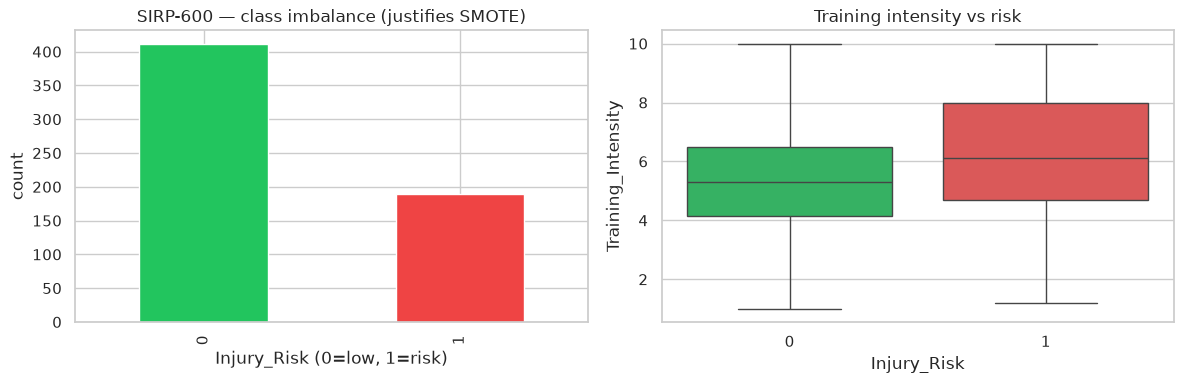

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sirp[SIRP_TARGET].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#22c55e', '#ef4444'])
axes[0].set_title('SIRP-600 — class imbalance (justifies SMOTE)')
axes[0].set_xlabel('Injury_Risk (0=low, 1=risk)')
axes[0].set_ylabel('count')

sns.boxplot(data=sirp, x=SIRP_TARGET, y='Training_Intensity', ax=axes[1],
            palette=['#22c55e', '#ef4444'])
axes[1].set_title('Training intensity vs risk')
plt.tight_layout(); plt.show()

## 3. Synthetic dataset (ACWR & time series)

In [5]:
from src.data.generate_synthetic import generate, DEFAULT_OUTPUT
from src.features.engineering import build_features

if DEFAULT_OUTPUT.exists():
    synth = pd.read_parquet(DEFAULT_OUTPUT)
else:
    synth = generate()
synth = build_features(synth)
print(synth.shape)
synth[['athlete_id','date','training_load','acwr','acwr_zone','soreness','risk_level']].head()

(146000, 31)


,athlete_id,date,training_load,acwr,acwr_zone,soreness,risk_level
0,0,2023-01-01,50.2,1.0,optimal,4.48,0
1,0,2023-01-02,72.9,1.0,optimal,3.29,0
2,0,2023-01-03,78.8,1.0,optimal,4.55,0
3,0,2023-01-04,36.8,1.0,optimal,2.02,0
4,0,2023-01-05,64.3,1.0,optimal,7.02,1


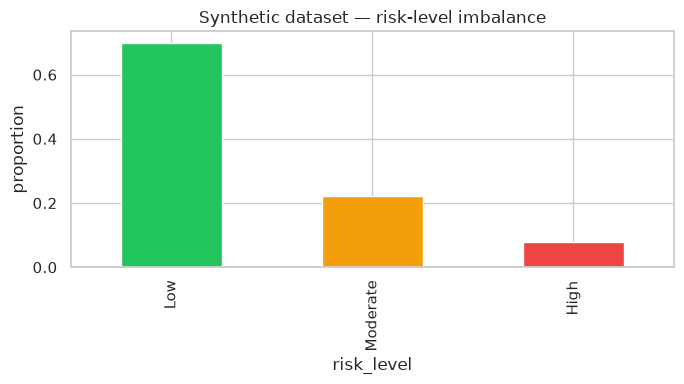

risk_level
Low         0.700
Moderate    0.221
High        0.079
Name: proportion, dtype: float64

In [6]:
# Imbalance of the 3 classes
labels = {0: 'Low', 1: 'Moderate', 2: 'High'}
dist = synth['risk_level'].map(labels).value_counts(normalize=True)
ax = dist.reindex(['Low','Moderate','High']).plot(
    kind='bar', color=['#22c55e','#f59e0b','#ef4444'], figsize=(7,4))
ax.set_title('Synthetic dataset — risk-level imbalance')
ax.set_ylabel('proportion'); plt.tight_layout(); plt.show()
dist.round(3)

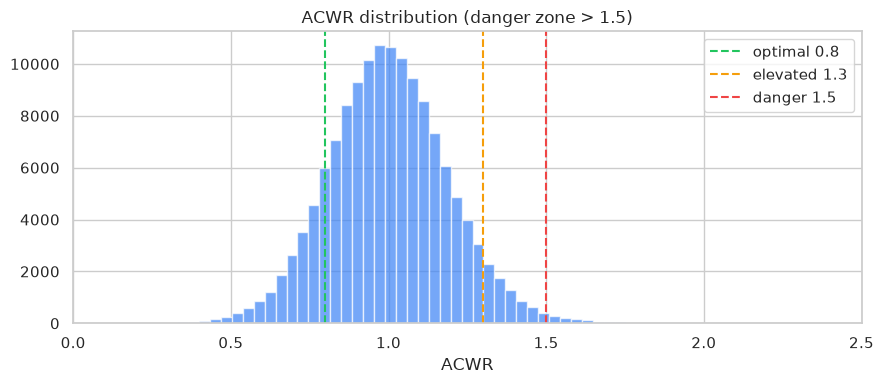

acwr_zone
optimal     0.802
under       0.139
elevated    0.051
danger      0.007
Name: proportion, dtype: float64

In [7]:
# ACWR distribution + business zones
stable = synth[synth['day'] >= 28]
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(stable['acwr'], bins=60, color='#3b82f6', alpha=0.7)
for x, c, lbl in [(0.8,'#22c55e','optimal 0.8'),(1.3,'#f59e0b','elevated 1.3'),(1.5,'#ef4444','danger 1.5')]:
    ax.axvline(x, color=c, linestyle='--', label=lbl)
ax.set_title('ACWR distribution (danger zone > 1.5)')
ax.set_xlabel('ACWR'); ax.legend(); ax.set_xlim(0, 2.5)
plt.tight_layout(); plt.show()
stable['acwr_zone'].value_counts(normalize=True).round(3)

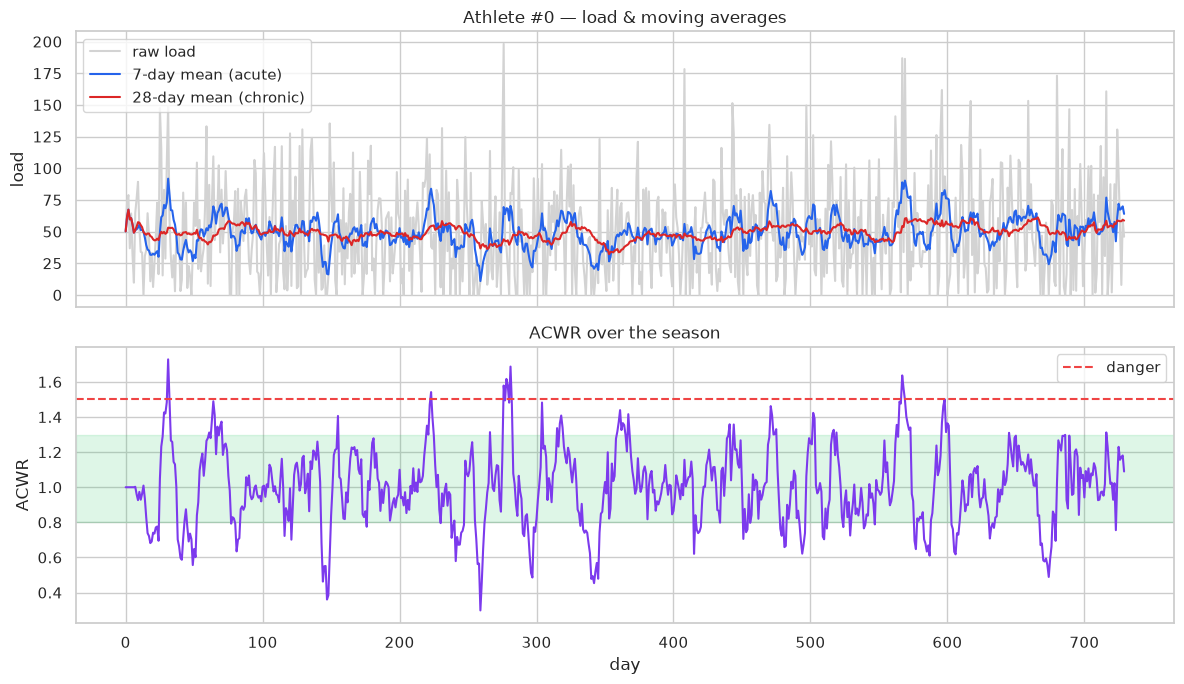

In [8]:
# One athlete's time series: load, 7/28-day rolling and ACWR
a = synth[synth['athlete_id'] == 0].sort_values('day')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1.plot(a['day'], a['training_load'], color='lightgray', label='raw load')
ax1.plot(a['day'], a['training_load_7d'], color='#2563eb', label='7-day mean (acute)')
ax1.plot(a['day'], a['training_load_28d'], color='#dc2626', label='28-day mean (chronic)')
ax1.set_title('Athlete #0 — load & moving averages'); ax1.legend(); ax1.set_ylabel('load')
ax2.plot(a['day'], a['acwr'], color='#7c3aed')
ax2.axhspan(0.8, 1.3, color='#22c55e', alpha=0.15)
ax2.axhline(1.5, color='#ef4444', linestyle='--', label='danger')
ax2.set_title('ACWR over the season'); ax2.set_xlabel('day'); ax2.set_ylabel('ACWR'); ax2.legend()
plt.tight_layout(); plt.show()

## 4. Correlations (synthetic dataset)

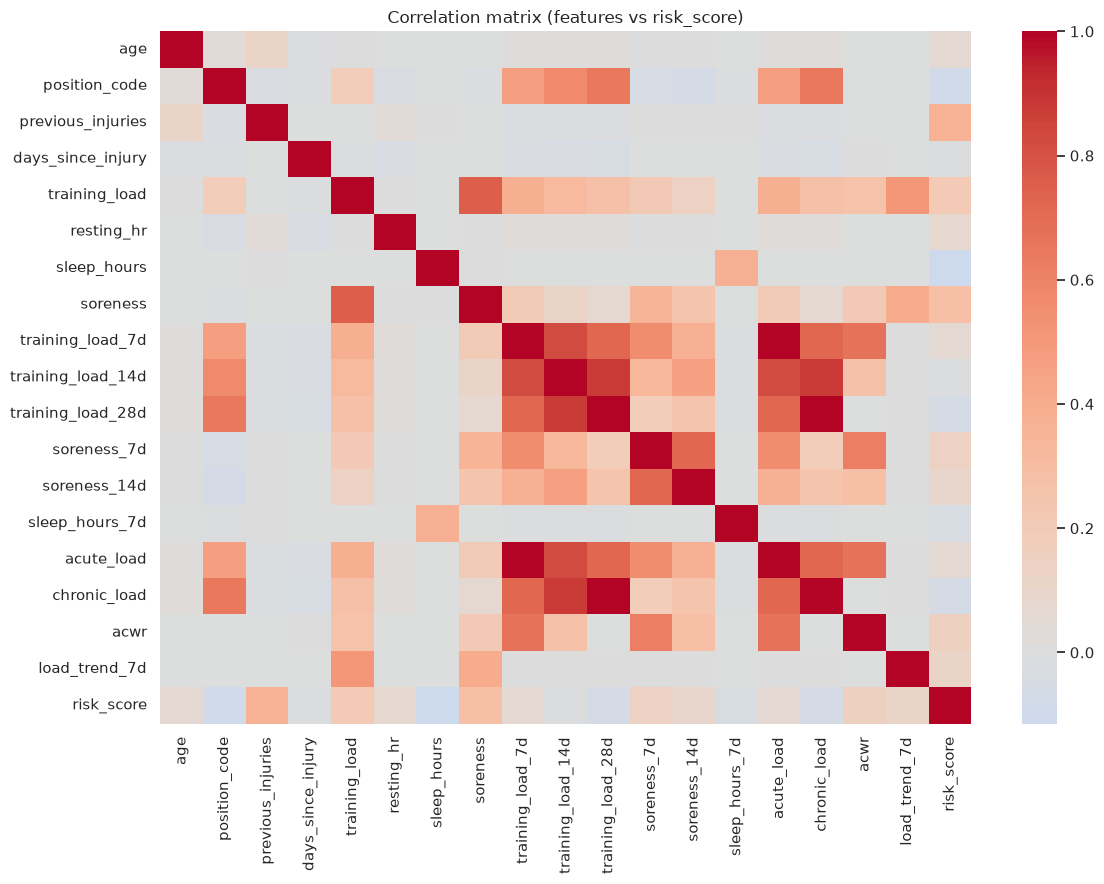

previous_injuries    0.373
soreness             0.288
training_load        0.211
acwr                 0.158
soreness_7d          0.148
load_trend_7d        0.114
soreness_14d         0.091
resting_hr           0.073
age                  0.060
acute_load           0.058
training_load_7d     0.058
days_since_injury   -0.008
training_load_14d   -0.010
sleep_hours_7d      -0.042
chronic_load        -0.059
training_load_28d   -0.059
position_code       -0.085
sleep_hours         -0.115
Name: risk_score, dtype: float64

In [9]:
from src.features.engineering import SYNTHETIC_FEATURE_COLS
corr = synth[SYNTHETIC_FEATURE_COLS + ['risk_score']].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation matrix (features vs risk_score)')
plt.tight_layout(); plt.show()

corr['risk_score'].drop('risk_score').sort_values(ascending=False).round(3)

## Conclusions

- **ACWR**, **soreness**, **injury history** and **sleep** are the factors most correlated with risk — consistent with the strength & conditioning literature.
- The class imbalance (synthetic ~70/22/8; SIRP-600 ~68/32) **justifies SMOTE**.
- Only the synthetic dataset enables a temporal ACWR → confirms the dual-track strategy.

➡️ Next: feature engineering (`src/features/engineering.py`), models (`src/models/train.py`), SHAP explainability (`src/visualization/shap_plots.py`).